In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
boston = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')


In [3]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [4]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## summarizing the stats of the dataset

In [5]:
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## check missing values

In [6]:
boston.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

## EDA

### correlation

In [7]:
boston.corr()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


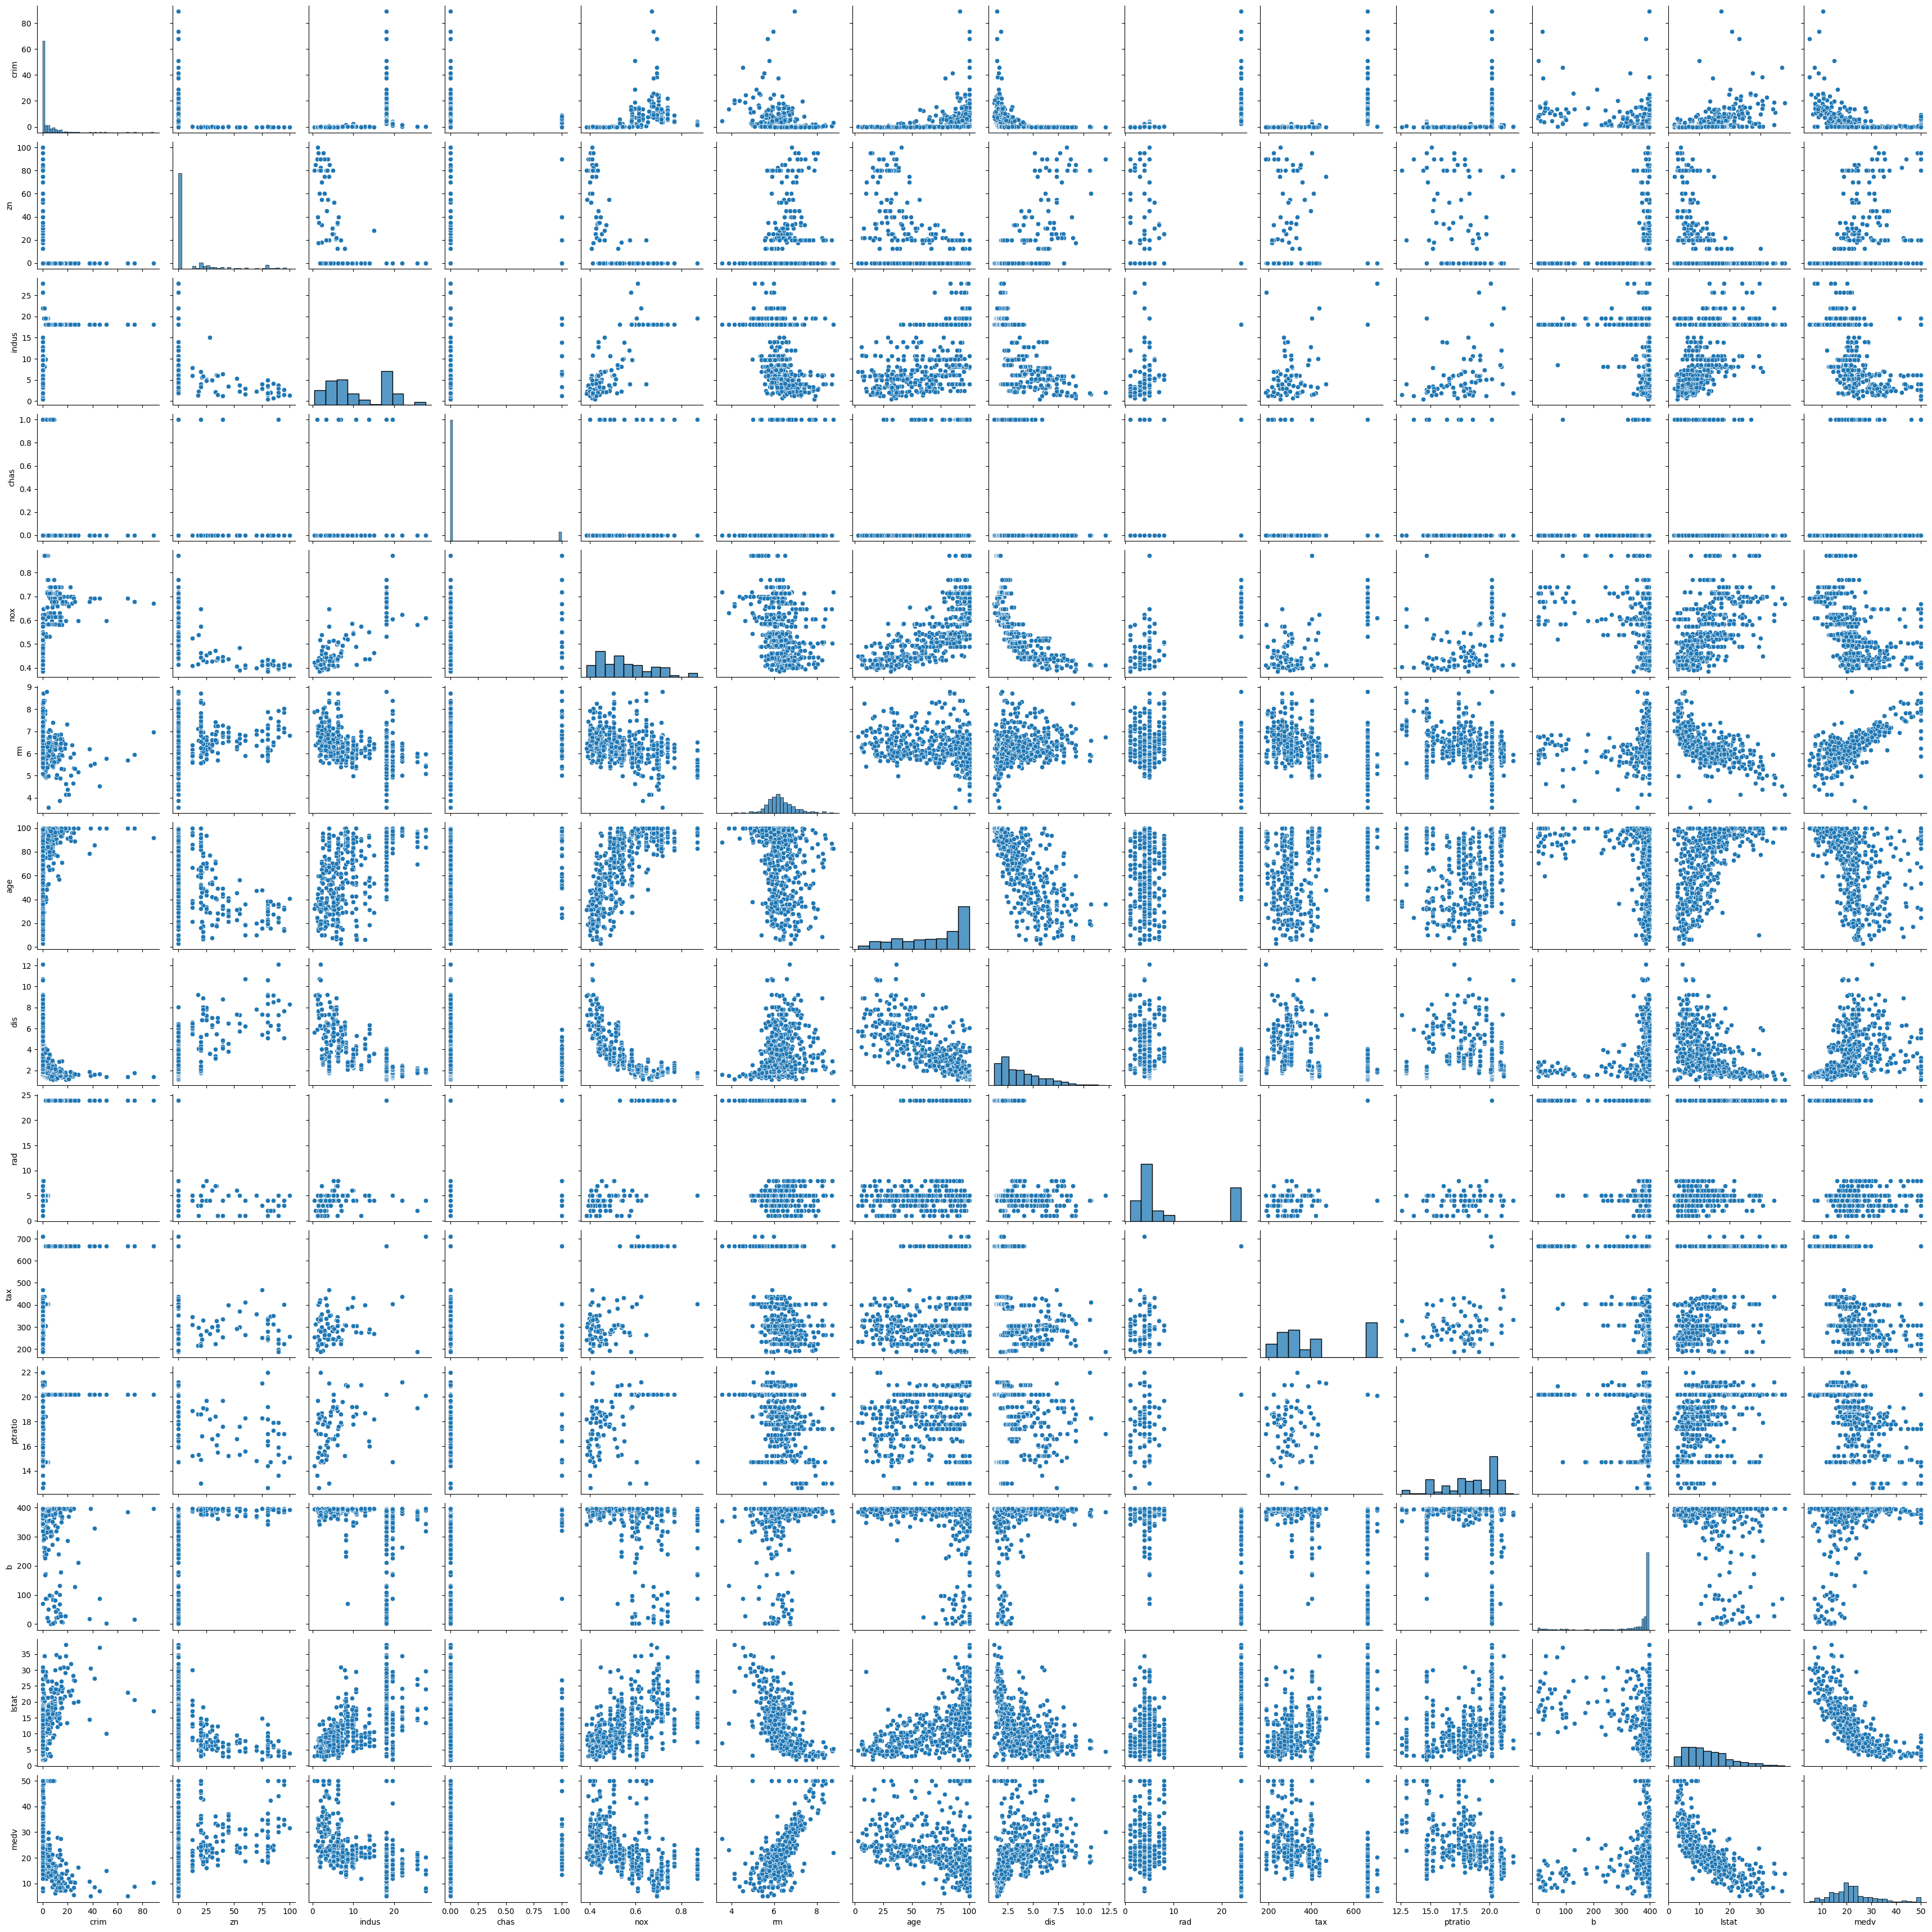

In [8]:
import seaborn as sns
sns.pairplot(boston)

Text(0, 0.5, 'Median Value of Homes')

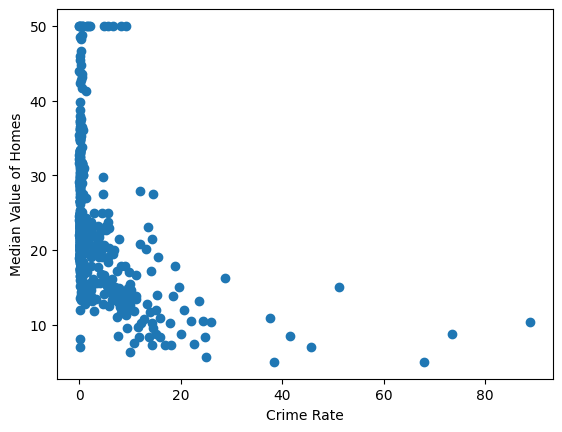

In [9]:
plt.scatter(boston['crim'],boston['medv'])
plt.xlabel('Crime Rate')
plt.ylabel('Median Value of Homes')

Text(0, 0.5, 'Median Value of Homes')

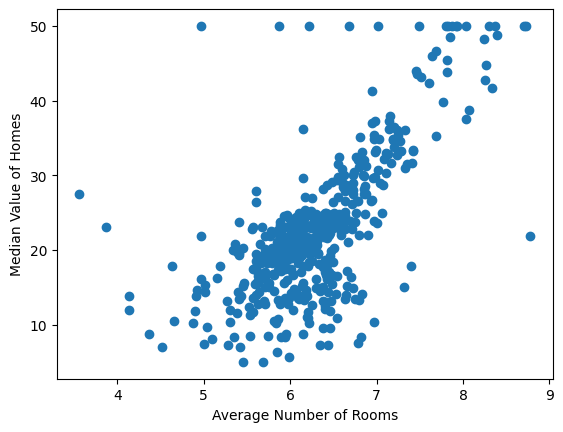

In [10]:
plt.scatter(boston['rm'],boston['medv'])
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median Value of Homes')

## regression plot for above plot or above two columns used in plot

<Axes: xlabel='rm', ylabel='medv'>

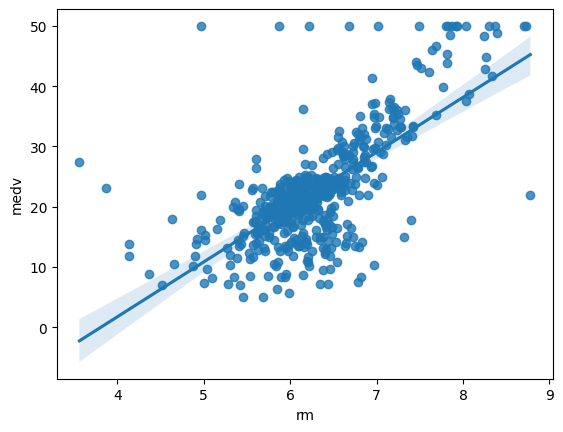

In [11]:
sns.regplot(x="rm",y="medv",data=boston)

<Axes: xlabel='lstat', ylabel='medv'>

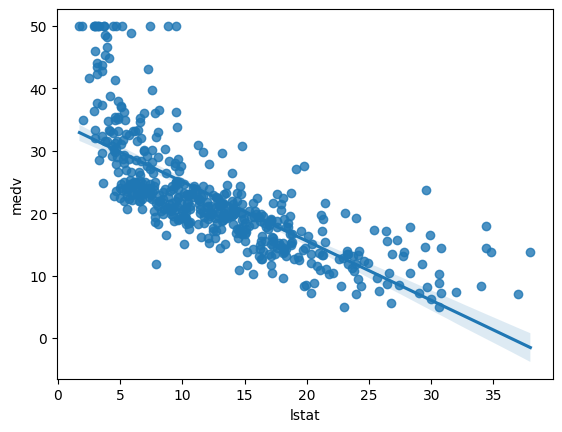

In [12]:
sns.regplot(x="lstat",y="medv",data=boston)

<Axes: xlabel='chas', ylabel='medv'>

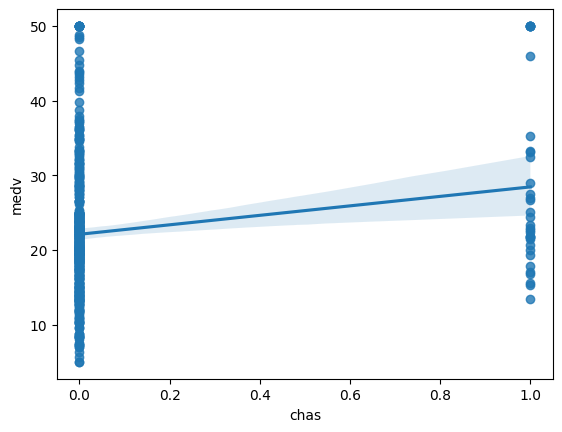

In [13]:
sns.regplot(x="chas",y="medv",data=boston)

<Axes: xlabel='ptratio', ylabel='medv'>

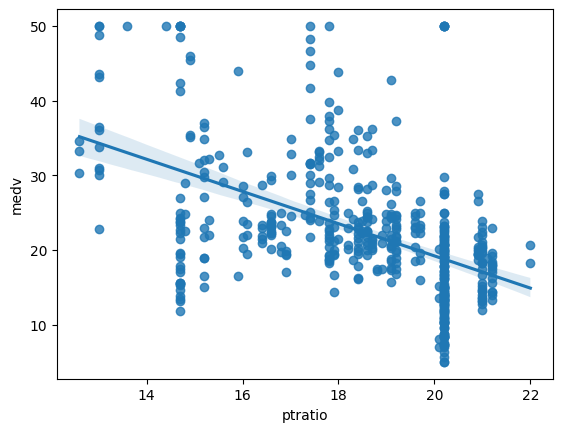

In [14]:
sns.regplot(x="ptratio",y="medv",data=boston)

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
x = boston.iloc[:,:-1]
y= boston.iloc[:,-1]

In [89]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [90]:
x_train.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
116,0.13158,0.0,10.01,0,0.547,6.176,72.5,2.7301,6,432,17.8,393.30,12.04
45,0.17142,0.0,6.91,0,0.448,5.682,33.8,5.1004,3,233,17.9,396.90,10.21
16,1.05393,0.0,8.14,0,0.538,5.935,29.3,4.4986,4,307,21.0,386.85,6.58
468,15.57570,0.0,18.10,0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13


# standarding dataset

In [91]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()

In [92]:
x_train=sc1.fit_transform(x_train)
x_test = sc1.transform(x_test)
x_train


array([[-0.41425879, -0.50512499, -1.29214218, ...,  0.18727079,
         0.39651419, -1.01531611],
       [-0.40200818, -0.50512499, -0.16208345, ..., -0.21208981,
         0.3870674 , -0.05366252],
       [-0.39721053, -0.50512499, -0.60948856, ..., -0.16771641,
         0.42854113, -0.31132373],
       ...,
       [-0.41604586,  3.03838247, -1.3166773 , ..., -0.56707702,
         0.35987906, -0.90549329],
       [ 0.92611293, -0.50512499,  1.00549958, ...,  0.8528718 ,
        -2.87841346,  1.52750437],
       [-0.39030549, -0.50512499, -0.37135358, ...,  1.16348561,
        -3.32828832, -0.25218837]], shape=(354, 13))

In [93]:
lf1 = LinearRegression()
lf1.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## print coefficients

In [94]:
print(lf1.coef_)
print(lf1.intercept_)

[-1.10834602  0.80843998  0.34313466  0.81386426 -1.79804295  2.913858
 -0.29893918 -2.94251148  2.09419303 -1.44706731 -2.05232232  1.02375187
 -3.88579002]
23.01581920903955


## on which params the model has been trained

In [95]:
lf1.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [98]:
data_point = [[0.00632, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98]]

In [101]:
new_data_point = sc1.transform(data_point)
new_data_point

c:\Users\venka\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.41709233,  0.29216419, -1.27338003, -0.28154625, -0.16513629,
         0.34715902, -0.13030059,  0.15267164, -0.97798895, -0.66777595,
        -1.32142483,  0.42854113, -1.04769976]])

In [100]:
pred1 = lf1.predict(new_data_point)
print(pred1)

[30.08649576]


Text(0, 0.5, 'Predicted Values')

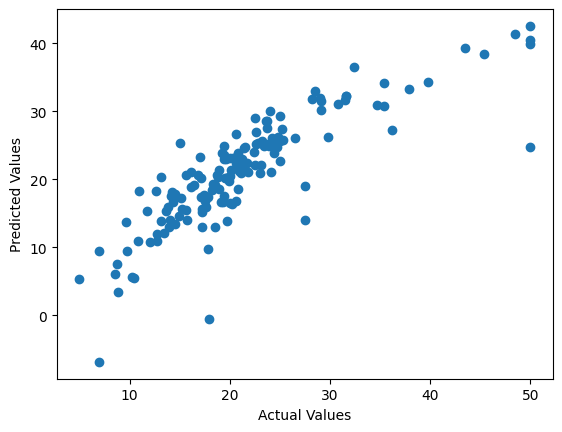

In [57]:
## plot a scatter plot of actual vs predicted values
plt.scatter(y_test,pred1)
plt.xlabel('Actual Values') 
plt.ylabel('Predicted Values')

## residuals (error)

In [58]:
res = y_test -pred1

In [59]:
res

173    -5.048960
274    -4.095014
491    -1.811193
72     -2.603213
452    -2.755280
         ...    
441    -0.303672
23      1.114059
225    10.016575
433    -2.382863
447    -5.685618
Name: medv, Length: 152, dtype: float64

## plot the residuals

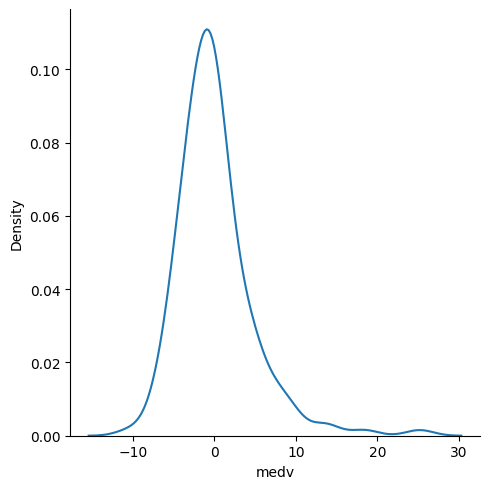

In [32]:
sns.displot(res,kind = 'kde')

## Scatter plot with respect to predictions and residulas
plot will be uniform (means model prdicts well)

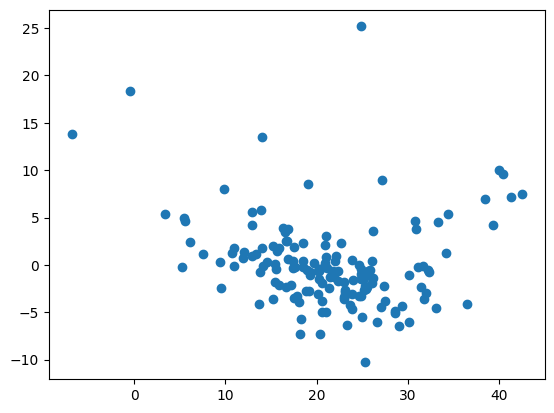

In [33]:
plt.scatter(pred1,res)

In [34]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error,mean_absolute_error
print("Mean Squared Error:", mean_squared_error(y_test,pred1))
print("Root Mean Squared Error:", root_mean_squared_error(y_test,pred1))
print("Mean Absolute Error:", mean_absolute_error(y_test,pred1))

Mean Squared Error: 21.517444231177212
Root Mean Squared Error: 4.638689926172821
Mean Absolute Error: 3.1627098714574053


## just a regression plot on actual and predicted values

In [35]:
data = pd.DataFrame({
    'pred1':pred1,
    'y_test':y_test
})


<Axes: xlabel='pred1', ylabel='y_test'>

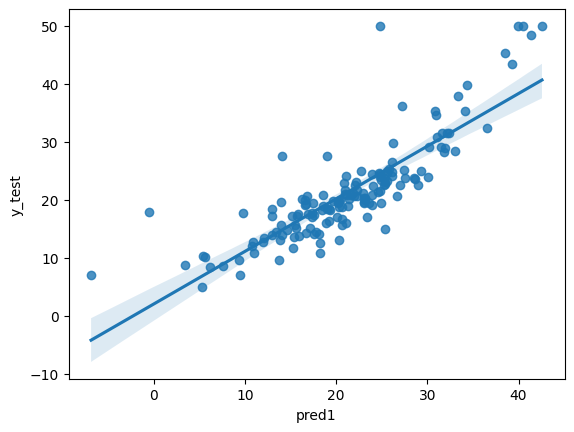

In [36]:
sns.regplot(x="pred1",y="y_test",data=data)

## R square and adjusted R square
(these are also an evaluation metrics)

In [37]:
from sklearn.metrics import r2_score
score = r2_score(y_test,pred1)
print("R-squared Score:", score)

R-squared Score: 0.7112260057484932


there is no libraury for adjusted r square we have to manually calculate it
## formula
### Adjusted R square = 1 - [(1-R2)*(n-1)/(n-k-1)]  (R2 means R square value above one)
          

In [38]:
 adj_r_square =1 - (1-score) * (len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

In [39]:
adj_r_square

0.6840226584639308

In [ ]:
data_point = [[0.00632, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296.0, 15.3, 396.9, 4.98]]

array([[6.32000000e-03, 1.80000000e+01, 2.31000000e+00, 3.51257002e-17,
        5.38000000e-01, 6.57500000e+00, 6.52000000e+01, 4.09000000e+00,
        1.00000000e+00, 2.96000000e+02, 1.53000000e+01, 3.96900000e+02,
        4.98000000e+00]])

In [81]:

data_point = sc1.fit_transform(data_point)
data_point

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [74]:
data_point.shape

(1, 13)

In [53]:
data_point = sc.transform(data_point)

In [82]:
pfg = lf1.predict(data_point)
pfg

array([23.01581921])

In [45]:
ans = boston.iloc[:1,-1].values
ans

array([24.])

In [46]:
if(pfg == ans):
    print("The predicted value is correct")
else:    print("The predicted value is incorrect")

The predicted value is incorrect


In [47]:
import pickle

In [48]:
pickle.dump(lf1,open('regression.pkl','wb'))

In [49]:
pic_model = pickle.load(open('regression.pkl','rb'))

In [50]:
pic_model.predict(data_point)

array([23.01581921])

In [103]:
pickle.dump(sc1,open('scaler1.pkl','wb'))